# Lecture 7 — Selecting the latent rank $k$ and regularization $\lambda$

The rank $k$ and regularization strength $\lambda$ are hyperparameters: $k$ controls the number of latent dimensions, while $\lambda$ controls the strength of the penalty on large latent factors.

This notebook selects them **sequentially**: first the latent rank $k$ is chosen using a fixed regularization strength, then the regularization strength $\lambda$ is chosen using the selected rank $k^{*}$. Each stage compares candidate values using held-out validation RMSE, and each stage keeps its own diagnostic plot, so both selection steps stay visible.

Because this is a synthetic matrix, the complete matrix is known and the hidden entries can be evaluated against the truth. Here those hidden entries play the role of held-out validation ratings. In a real recommender system, the analogous comparison would use a validation split of known ratings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matrix_factorization import factorize, reconstruct

np.set_printoptions(precision=3, suppress=True)

## 1. Generate the synthetic rating matrix

The true matrix has rank $2$. We hide roughly 45% of its entries and keep the rest as the observed matrix $Y$. The hidden entries are used only to compute the validation RMSE for each candidate hyperparameter; they are never given to the factorization algorithm.

In [2]:
rng = np.random.default_rng(42)
n_users, n_movies, k_true = 8, 7, 2
U_true = rng.normal(size=(n_users, k_true))
V_true = rng.normal(size=(n_movies, k_true))
X_true = U_true @ V_true.T

mask = rng.random((n_users, n_movies)) < 0.55
Y_synth = np.where(mask, X_true, np.nan)

candidate_k = range(1, 6)
candidate_lambda = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]

## 2. Select $k$ first, using a fixed $\lambda$

To isolate the effect of rank, we temporarily fix $\lambda$ at a default value $\lambda_0$ taken from the middle of the candidate grid, and compare candidate values of $k$ using validation RMSE:

$$
k^{*}=\underset{k}{\arg\min}\;RMSE_{\mathrm{val}}(k,\lambda_0).
$$

This stage answers a narrower question than the full joint selection: given a reasonable, fixed regularization strength, how many latent dimensions does the data support?

In [3]:
default_lambda = 1e-2
k_results = []

for k in candidate_k:
    U_hat, V_hat, history = factorize(Y_synth, k=k, lambda_=default_lambda, seed=1)
    X_hat = reconstruct(U_hat, V_hat)

    observed_rmse = np.sqrt(np.mean((X_hat[mask] - X_true[mask])**2))
    validation_rmse = np.sqrt(np.mean((X_hat[~mask] - X_true[~mask])**2))
    k_results.append({
        'k': k,
        'lambda': default_lambda,
        'observed_rmse': observed_rmse,
        'validation_rmse': validation_rmse,
    })

k_results = pd.DataFrame(k_results)
print(k_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_k_row = k_results.loc[k_results['validation_rmse'].idxmin()]
best_k = int(best_k_row['k'])

print(f'\nSelected k*: {best_k} (lambda fixed at {default_lambda:g} for this stage)')
print(f'Validation RMSE at k*: {best_k_row["validation_rmse"]:.4f}')

 k  lambda  observed_rmse  validation_rmse
 1  0.0100         0.2632           0.5457
 2  0.0100         0.0065           0.1574
 3  0.0100         0.0055           0.2755
 4  0.0100         0.0043           0.3034
 5  0.0100         0.0043           0.2854

Selected k*: 2 (lambda fixed at 0.01 for this stage)
Validation RMSE at k*: 0.1574


### Validation RMSE vs $k$

The plot shows how validation RMSE changes with $k$ while $\lambda$ is held fixed at $\lambda_0$. The marked point is the selected $k^{*}$, the rank with the lowest validation RMSE at this stage.

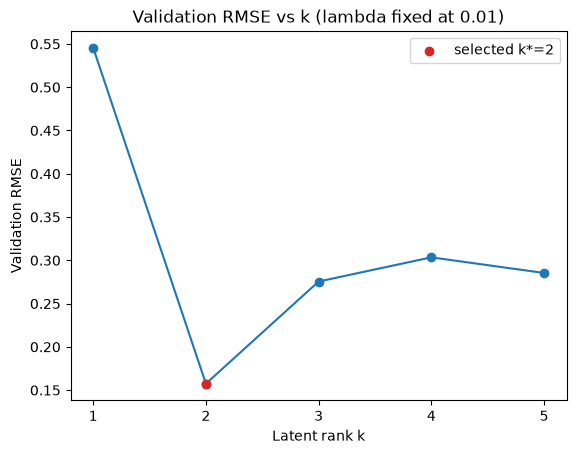

In [4]:
fig, ax = plt.subplots()

ax.plot(k_results['k'], k_results['validation_rmse'], marker='o', color='tab:blue')
ax.scatter([best_k], [best_k_row['validation_rmse']], color='tab:red', zorder=5,
           label=f'selected k*={best_k}')

ax.set_xlabel('Latent rank k')
ax.set_ylabel('Validation RMSE')
ax.set_title(f'Validation RMSE vs k (lambda fixed at {default_lambda:g})')
ax.set_xticks(list(candidate_k))
ax.legend()
plt.show()

## 3. Select $\lambda$ next, using the selected $k^{*}$

With the rank fixed at $k^{*}$, we now sweep $\lambda$ over a logarithmic grid, because useful regularization strengths can differ by orders of magnitude. We select the value that minimizes validation RMSE at the chosen rank:

$$
\lambda^{*}=\underset{\lambda}{\arg\min}\;RMSE_{\mathrm{val}}(k^{*},\lambda).
$$

This two-stage procedure — $k^{*}$ first, then $\lambda^{*}$ at that $k^{*}$ — is a practical approximation to jointly minimizing over both hyperparameters at once. It costs far fewer model fits than a full $(k,\lambda)$ grid, at the cost of assuming the best $\lambda$ does not depend strongly on $k$. That assumption is reasonable here and keeps the two selection steps easy to inspect separately, one plot per hyperparameter.

In [5]:
lambda_results = []

for lam in candidate_lambda:
    U_hat, V_hat, history = factorize(Y_synth, k=best_k, lambda_=lam, seed=1)
    X_hat = reconstruct(U_hat, V_hat)

    observed_rmse = np.sqrt(np.mean((X_hat[mask] - X_true[mask])**2))
    validation_rmse = np.sqrt(np.mean((X_hat[~mask] - X_true[~mask])**2))
    lambda_results.append({
        'k': best_k,
        'lambda': lam,
        'observed_rmse': observed_rmse,
        'validation_rmse': validation_rmse,
    })

lambda_results = pd.DataFrame(lambda_results)
print(lambda_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_lambda_row = lambda_results.loc[lambda_results['validation_rmse'].idxmin()]
best_lambda = float(best_lambda_row['lambda'])

print(f'\nSelected lambda*: {best_lambda:g} (k fixed at k*={best_k} for this stage)')
print(f'Best validation RMSE: {best_lambda_row["validation_rmse"]:.4f}')

 k  lambda  observed_rmse  validation_rmse
 2  0.0001         0.0007           0.0466
 2  0.0010         0.0013           0.0885
 2  0.0100         0.0065           0.1574
 2  0.1000         0.0469           0.2319
 2  1.0000         0.3260           0.5503

Selected lambda*: 0.0001 (k fixed at k*=2 for this stage)
Best validation RMSE: 0.0466


### Validation RMSE vs $\lambda$

The plot shows how validation RMSE changes with $\lambda$ while $k$ is held fixed at $k^{*}$. A very small $\lambda$ allows the factors more freedom to fit the observed data, while a large $\lambda$ penalizes large factor values more strongly. The marked point is the selected $\lambda^{*}$.

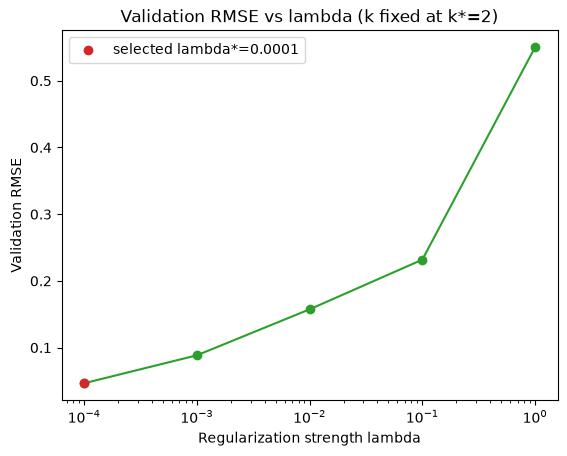

In [6]:
fig, ax = plt.subplots()

ax.plot(lambda_results['lambda'], lambda_results['validation_rmse'], marker='o', color='tab:green')
ax.scatter([best_lambda], [best_lambda_row['validation_rmse']], color='tab:red', zorder=5,
           label=f'selected lambda*={best_lambda:g}')

ax.set_xscale('log')
ax.set_xlabel('Regularization strength lambda')
ax.set_ylabel('Validation RMSE')
ax.set_title(f'Validation RMSE vs lambda (k fixed at k*={best_k})')
ax.legend()
plt.show()

## 4. Selected hyperparameters

The two stages above give the selected pair $(k^{*},\lambda^{*})$, printed at the end of each stage's code cell.

Notebook `03_final_matrix_completion.ipynb` uses this pair to fit the final model and predict the missing entries. If a stronger guarantee that $k^{*}$ and $\lambda^{*}$ jointly minimize validation RMSE is needed, the two candidate grids above can instead be combined into one full $(k,\lambda)$ grid search; that costs more model fits but removes the sequential-selection assumption.

## Interpretation

The important quantity at every stage is the **held-out/validation RMSE**. Increasing $k$ gives the model more flexibility, so the observed error can decrease. But lower observed error does not necessarily mean better predictions for unseen entries — this is why $k^{*}$ is chosen from the validation-RMSE-vs-$k$ plot rather than by picking the largest available rank.

In this synthetic experiment the true matrix was generated with rank $2$. The held-out RMSE at the $k$-selection stage can favor this lower-dimensional model, while larger ranks may fit the observed entries slightly better without improving the held-out predictions.

The same validation principle is used for $\lambda$, now at the fixed rank $k^{*}$. Very weak regularization may allow the factors to become large, while very strong regularization can restrict the model too much. The validation-RMSE-vs-$\lambda$ plot helps identify a useful balance.

For a real recommender system, the missing entries are not available as ground truth. Instead, known ratings would be split into training and validation sets, and $k$ and $\lambda$ would be selected in the same two stages using the validation score.

## What to remember

- $k$ is the number of latent dimensions. It is a hyperparameter, not a learned rating or an entry of $U$ or $V$.
- $\lambda$ controls the strength of regularization. It is also a hyperparameter.
- This notebook selects hyperparameters in **two sequential stages**: $k^{*}$ first at a fixed default $\lambda_0$, then $\lambda^{*}$ at the fixed $k^{*}$.
- Each stage has its own validation-RMSE plot — one plotted against $k$, the other plotted against $\lambda$ — so both selection steps stay visible rather than being collapsed into a single figure.
- Candidate values of $\lambda$ are searched on a logarithmic scale.
- Sequential selection is a practical approximation to jointly minimizing over $(k,\lambda)$ pairs; a full grid over both hyperparameters removes the sequential assumption at the cost of more model fits.
- After model selection, notebook `03_final_matrix_completion.ipynb` refits the model using $(k^{*},\lambda^{*})$ and predicts genuinely missing ratings.
- In a real recommender system, validation ratings are known ratings temporarily held out for model selection; genuinely missing ratings have no known target value.